# Topic Modelling Starter

This notebook sets up a reusable workflow for LDA and BERTopic on the news dataset.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from gensim import corpora
from gensim.models import CoherenceModel

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer


In [2]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("vader_lexicon")

[nltk_data] Downloading package punkt to /Users/willevans/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/willevans/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/willevans/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [7]:
DATA_PATH = r"C:\Users\WEWL\OneDrive - Capco\Desktop\ADS Assessment\Data\NLP_data.csv"

TEXT_COLUMN = "content"
SAMPLE_SIZE = None

df = pd.read_csv(DATA_PATH)
print(df.shape)

df = df.dropna(subset=[TEXT_COLUMN]).copy()
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
df = df.dropna(subset=["published_at"]).copy()
df = df[["article_id","source_name", "title", "category", "published_at", TEXT_COLUMN]].copy()

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

df.head()
print(df.shape)

(105375, 12)
(62932, 6)


In [6]:
df = pd.read_csv(r"/Users/willevans/Desktop/working_topic_clean.csv")
print(df.shape)


(62932, 8)


In [ ]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [token for token in tokens if len(token) > 2 and token not in stop_words]
    return tokens

df["tokens"] = df[TEXT_COLUMN].apply(clean_text)
df["clean_text"] = df["tokens"].apply(lambda tokens: " ".join(tokens))
df["published_date"] = df["published_at"].dt.date
df["published_year"] = df["published_at"].dt.year
df["published_month"] = df["published_at"].dt.to_period("M").astype(str)

sia = SentimentIntensityAnalyzer()
df["sentiment_score"] = df[TEXT_COLUMN].apply(lambda text: sia.polarity_scores(str(text))["compound"])
df["sentiment_label"] = pd.cut(
    df["sentiment_score"],
    bins=[-1.0, -0.05, 0.05, 1.0],
    labels=["Negative", "Neutral", "Positive"]
)

df[["title", "category", "published_at", "published_month", "sentiment_label", "clean_text"]].head()


NameError: name 'TEXT_COLUMN' is not defined

In [9]:

print(df.shape)

(62932, 13)


In [8]:
print(df.shape)
print(df["category"].fillna("Unknown").value_counts().head(10))
df[["published_at", "published_month", "sentiment_score", "sentiment_label"]].head()

date_min = df["published_at"].min()
date_max = df["published_at"].max()

#print("Latest date:", date_max.date())

#print("Earliest date:", date_min.date())
#print("Date range:", date_max - date_min)

(62932, 8)
category
Finance     842
News        820
Jobs        795
Weather     776
Cars        771
Politics    764
Games       743
Love        728
Food        723
Music       719
Name: count, dtype: int64


In [9]:
df["text_len"] = df[TEXT_COLUMN].fillna("").astype(str).apply(lambda x: len(x))
df["title_len"] = df["title"].fillna("").astype(str).apply(lambda x: len(x))


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))
sns.histplot(df["text_len"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Article Text Length")
axes[0].set_xlabel("Text Length")
axes[0].set_ylabel("Frequency")

sns.histplot(df["title_len"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Title Length")
axes[1].set_xlabel("Title Length")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


NameError: name 'TEXT_COLUMN' is not defined

In [10]:
top_sources = (
    df["source_name"]
    .value_counts()
    .reset_index()
    .head(20)
)

top_sources.columns = ["source_name", "count"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_sources, x="source_name", y="count", palette="flare")

plt.title("Top 20 Sources by Article Count")
plt.xlabel("Source Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


KeyError: 'source_name'

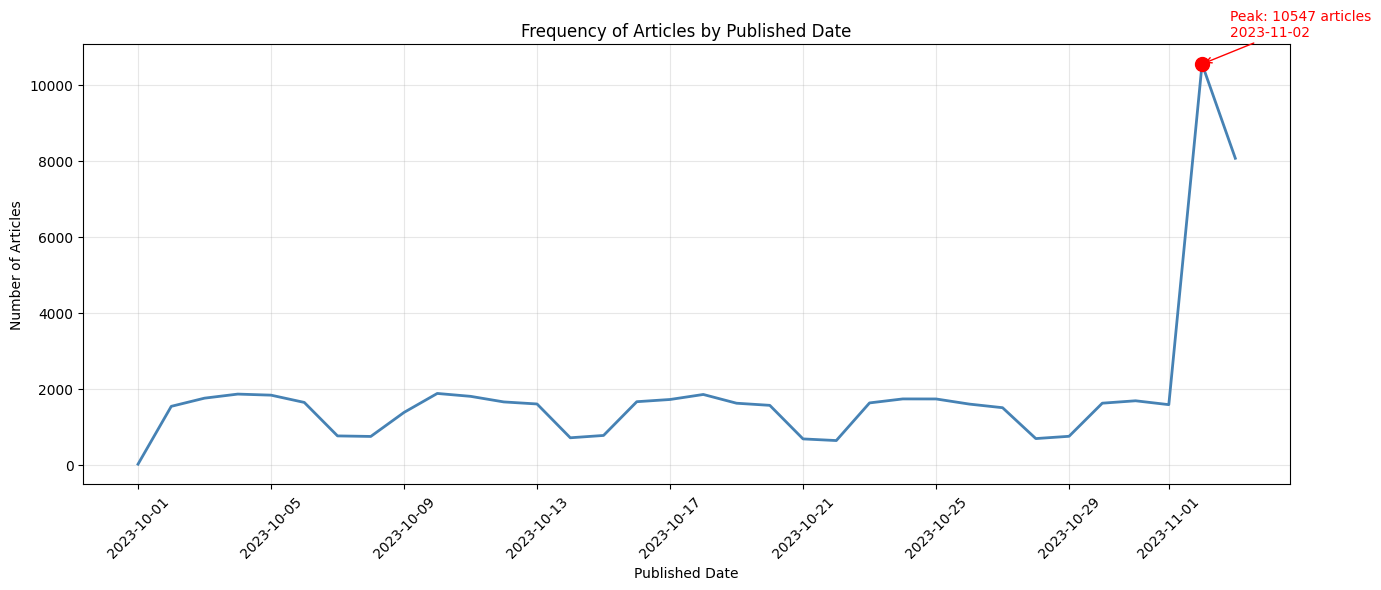

In [14]:
# Ensure dates are in datetime format
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)

articles_df = df.dropna(subset=["published_at"]).copy()
articles_df["published_date"] = articles_df["published_at"].dt.date

articles_by_date = (
    articles_df.groupby("published_date")
    .size()
    .reset_index(name="article_count")
)

articles_by_date["published_date"] = pd.to_datetime(articles_by_date["published_date"])

# Find peak
peak_row = articles_by_date.loc[articles_by_date["article_count"].idxmax()]

plt.figure(figsize=(14, 6))
plt.plot(
    articles_by_date["published_date"],
    articles_by_date["article_count"],
    color="steelblue",
    linewidth=2
)

# Highlight peak
plt.scatter(
    peak_row["published_date"],
    peak_row["article_count"],
    color="red",
    s=100,
    zorder=5
)

plt.annotate(
    f'Peak: {peak_row["article_count"]} articles\n{peak_row["published_date"].date()}',
    xy=(peak_row["published_date"], peak_row["article_count"]),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10,
    color="red"
)

plt.title("Frequency of Articles by Published Date")
plt.xlabel("Published Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

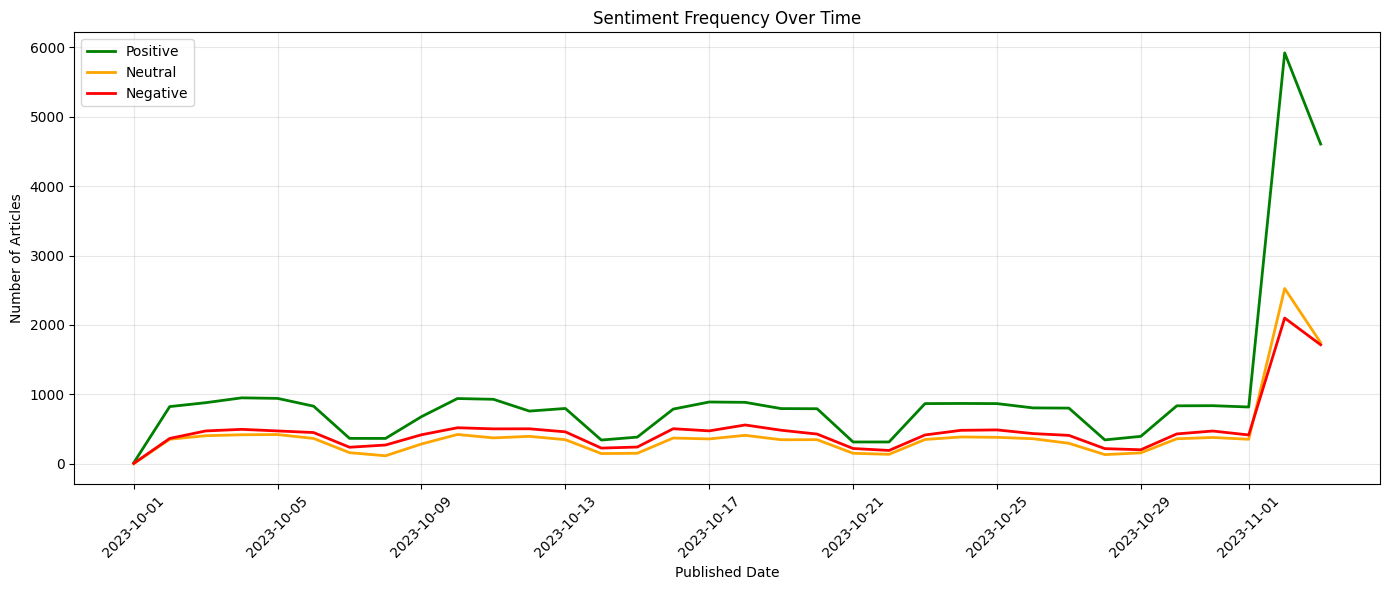

In [15]:
df["sentiment_label"] = pd.cut(
    df["sentiment_score"],
    bins=[-1.0, -0.05, 0.05, 1.0],
    labels=["Negative", "Neutral", "Positive"]
)

df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
sentiment_df = df.dropna(subset=["published_at"]).copy()
sentiment_df["published_date"] = sentiment_df["published_at"].dt.date

sentiment_counts = (
    sentiment_df.groupby(["published_date", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)

for col in ["Positive", "Neutral", "Negative"]:
    if col not in sentiment_counts.columns:
        sentiment_counts[col] = 0

sentiment_counts = sentiment_counts.sort_index()
sentiment_counts.index = pd.to_datetime(sentiment_counts.index)

plt.figure(figsize=(14, 6))
plt.plot(sentiment_counts.index, sentiment_counts["Positive"], color="green", linewidth=2, label="Positive")
plt.plot(sentiment_counts.index, sentiment_counts["Neutral"], color="orange", linewidth=2, label="Neutral")
plt.plot(sentiment_counts.index, sentiment_counts["Negative"], color="red", linewidth=2, label="Negative")

plt.title("Sentiment Frequency Over Time")
plt.xlabel("Published Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(
    stop_words="english",
    max_df=0.90,
    min_df=20,
    ngram_range=(1, 2)
)

doc_term_matrix = vectorizer.fit_transform(df["clean_text"])

In [12]:
for n in [5, 8, 10, 12]:
    lda_model = LatentDirichletAllocation(
        n_components=n,
        random_state=42,
        learning_method="batch"
    )
    lda_model.fit(doc_term_matrix)
    print(f"\nTop words for {n} topics:")
    feature_names = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(lda_model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")


Top words for 5 topics:
Topic 1: getty, images, getty images, new, year, years, city, photo, team, university
Topic 2: said, israel, president, united, october, hamas, gaza, minister, people, state
Topic 3: new, like, time, world, year, season, video, games, series, best
Topic 4: world, news, cup, world cup, report, daily, england, live, free, africa
Topic 5: company, new, report, apple, market, announced, free, quarter, according, year

Top words for 8 topics:
Topic 1: getty, images, getty images, new, apple, health, school, artificial, intelligence, artificial intelligence
Topic 2: israel, said, president, hamas, gaza, united, october, minister, state, war
Topic 3: new, like, time, video, season, series, best, know, life, world
Topic 4: news, report, daily, research, free, morning, stories, reporting, sign, world
Topic 5: company, report, quarter, new, free, announced, google, apple, according, free report
Topic 6: new, globe, nov, global, newswire, globe newswire, climate, market, 

In [16]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\\S+|www\\S+", " ", text)
    text = re.sub(r"[^a-z\\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if len(t) > 2 and t not in stop_words]
    return tokens

# Ensure tokens exist
df["tokens"] = df["clean_text"].apply(clean_text)
df["dictionary"] = df["tokens"]  # optional sanity column
print("tokens created:", df["tokens"].head(2).tolist())

df["clean_text"] = df["tokens"].apply(lambda tokens: " ".join(tokens))

coherence_scores = {}

dictionary = corpora.Dictionary(df["tokens"])

for n in [5, 8, 10, 12]:
    lda_model = LatentDirichletAllocation(
        n_components=n,
        random_state=42,
        learning_method="batch"
    )
    lda_model.fit(doc_term_matrix)
    
    topic_terms = []
    for topic in lda_model.components_:
        top_indices = topic.argsort()[:-11:-1]
        topic_terms.append([feature_names[i] for i in top_indices])
    
    coherence_model = CoherenceModel(
        topics=topic_terms,
        texts=df["tokens"],
        dictionary=dictionary,
        coherence="c_v"
    )
    coherence_scores[n] = coherence_model.get_coherence()

print("Coherence scores for different k:")
for k, score in coherence_scores.items():
    print(f"k={k}: {score:.4f}")

tokens created: [['secretary', 'general', 'antonio', 'guterres', 'urged', 'world', 'monday', 'stop', 'madness', 'climate', 'change', 'visited', 'himalayan', 'regions', 'struggling', 'rapidly', 'melting', 'glaciers', 'witness', 'devastatin', 'chars'], ['randeboo', 'web', 'autumn', 'winter', 'nepal', 'handmade', 'ram', 'vest', 'nepal', 'handmade', 'ram', 'knit', 'web', 'nepal', 'handmade', 'ram', 'vest', 'gray', 'ivory', 'chars']]
Coherence scores for different k:
k=5: 0.4962
k=8: 0.5302
k=10: 0.5419
k=12: 0.5016


In [20]:
N_TOPICS = 10

vectorizer = CountVectorizer(max_df=0.95, min_df=10, stop_words="english")
doc_term_matrix = vectorizer.fit_transform(df["clean_text"])

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="batch"
)
lda_model.fit(doc_term_matrix)

# Print top words for each topic
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")


Topic 1: new, time, like, season, year, series, years, day, film, world
Topic 2: new, google, data, digital, social, intelligence, use, information, users, help
Topic 3: market, year, nov, global, new, globe, newswire, world, according, report
Topic 4: president, said, minister, government, country, united, china, october, state, ukraine
Topic 5: company, news, million, bank, business, bitcoin, new, energy, group, billion
Topic 6: new, getty, images, photo, year, city, university, health, york, home
Topic 7: world, cup, new, video, england, best, day, youtube, amazon, page
Topic 8: house, president, trump, new, space, donald, comments, images, washington, said
Topic 9: report, free, company, apple, quarter, shares, nyse, nasdaq, according, commission
Topic 10: israel, hamas, gaza, war, israeli, attack, said, sam, october, bankman


In [21]:
# Assign each document to its dominant LDA topic
lda_topic_matrix = lda_model.transform(doc_term_matrix)
df["lda_topic"] = lda_topic_matrix.argmax(axis=1)


Topic 3
Number of articles: 4249
Average sentiment score: 0.1427176512120499
sentiment_label
Positive    2192
Neutral     1037
Negative    1020
Name: count, dtype: int64

Topic 5
Number of articles: 6411
Average sentiment score: 0.22874417407580722
sentiment_label
Positive    3842
Neutral     1563
Negative    1006
Name: count, dtype: int64

Topic 10
Number of articles: 5220
Average sentiment score: -0.32712524904214557
sentiment_label
Negative    3453
Positive    1094
Neutral      673
Name: count, dtype: int64


/var/folders/m4/py2v9t557sn5pwgbcr52g5g40000gn/T/ipykernel_20102/1608882728.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=topic_summary, x="Topic Name", y="mean", palette="coolwarm")


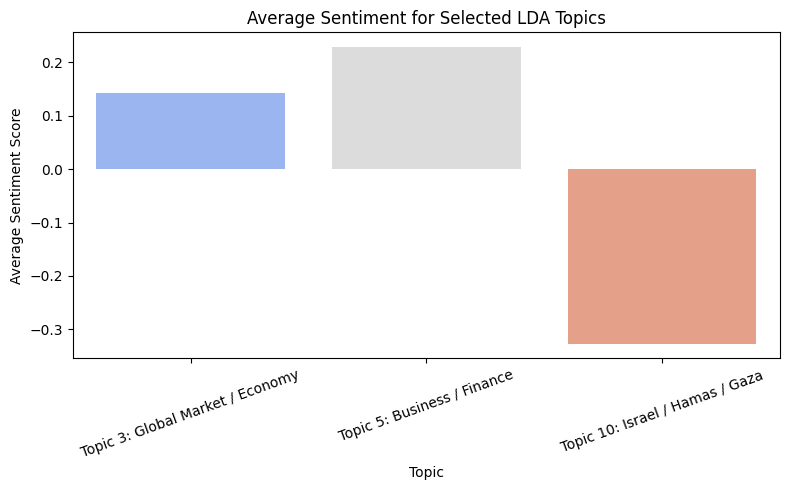

In [25]:
selected_topics = [2, 4, 9]

for topic_id in selected_topics:
    topic_df = df[df["lda_topic"] == topic_id].copy()

    print(f"\nTopic {topic_id + 1}")
    print("Number of articles:", topic_df.shape[0])
    print("Average sentiment score:", topic_df["sentiment_score"].mean())
    print(topic_df["sentiment_label"].value_counts(dropna=False))

# Ensure all selected topics are included, even if no articles
all_topics_df = pd.DataFrame({"lda_topic": selected_topics})

topic_summary = (
    df[df["lda_topic"].isin(selected_topics)]
    .groupby("lda_topic")["sentiment_score"]
    .agg(["mean", "count"])
    .reset_index()
)

topic_summary = all_topics_df.merge(topic_summary, on="lda_topic", how="left").fillna({"mean": 0, "count": 0})

topic_mapping = {
    2: "Topic 3: Global Market / Economy",
    4: "Topic 5: Business / Finance",
    9: "Topic 10: Israel / Hamas / Gaza"
}

topic_summary["Topic Name"] = topic_summary["lda_topic"].map(topic_mapping)

plt.figure(figsize=(8, 5))
sns.barplot(data=topic_summary, x="Topic Name", y="mean", palette="coolwarm")
plt.title("Average Sentiment for Selected LDA Topics")
plt.xlabel("Topic")
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95,
    min_df=10,
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_text"])
feature_names = tfidf_vectorizer.get_feature_names_out()

In [19]:
# ahahha this is the NMF version of the coherence loop
# same idea as LDA: try a few topic numbers and see which one gives the best coherence

dictionary = corpora.Dictionary(df["tokens"])
nmf_coherence_scores = {}

for k in [5, 8, 10, 12]:
    nmf_model = NMF(n_components=k, random_state=42)
    nmf_model.fit(tfidf_matrix)

    topic_terms = []
    for topic in nmf_model.components_:
        top_indices = topic.argsort()[:-11:-1]
        topic_terms.append([feature_names[i] for i in top_indices])

    coherence_model = CoherenceModel(
        topics=topic_terms,
        texts=df["tokens"],
        dictionary=dictionary,
        coherence="c_v"
    )

    nmf_coherence_scores[k] = coherence_model.get_coherence()

print("NMF Coherence scores for different k:")
for k, score in nmf_coherence_scores.items():
    print(f"k={k}: {score:.4f}")

best_nmf_k = max(nmf_coherence_scores, key=nmf_coherence_scores.get)
print(f"Best NMF k based on coherence: {best_nmf_k}")


NMF Coherence scores for different k:
k=5: 0.7968
k=8: 0.7947
k=10: 0.8078
k=12: 0.7843
Best NMF k based on coherence: 10


In [30]:
# ahahha now refit NMF using the best number of topics from coherence
nmf_model = NMF(n_components=10, random_state=42)
nmf_model.fit(tfidf_matrix)

feature_names = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {topic_idx + 1}: {", ".join(top_words)}")

nmf_topic_matrix = nmf_model.transform(tfidf_matrix)
df["nmf_topic"] = nmf_topic_matrix.argmax(axis=1)




Topic 1: year, said, getty, images, october, president, time, people, years, day
Topic 2: report, free, quarter, nyse, shares, according, recent, company, filing, nasdaq
Topic 3: news, stories, latest, live, cbs, breaking, analysis, features, coverage, beat
Topic 4: transmit, browsing, stored, collect, providers, personal, ads, data, information, device
Topic 5: page, adafruit, publishes, interviews, standards, wider, intended, writing, video, guide
Topic 6: israel, hamas, gaza, israeli, war, attack, palestinian, strip, conflict, group
Topic 7: world, cup, rugby, england, south, africa, table, cricket, final, zealand
Topic 8: commission, affiliate, links, advertising, earn, products, amazon, program, independently, purchase
Topic 9: newswire, globe, global, nov, market, billion, company, dublin, oct, added
Topic 10: new, york, apple, future, media, space, group, floor, street, publisher


In [28]:
# Print top 10 words for each NMF topic
feature_names = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"NMF Topic {topic_idx + 1}: {', '.join(top_words)}")


NMF Topic 1: year, said, president, october, united, people, time, minister, years, day
NMF Topic 2: report, free, quarter, nyse, shares, according, recent, company, filing, nasdaq
NMF Topic 3: news, stories, latest, live, cbs, breaking, analysis, features, coverage, beat
NMF Topic 4: transmit, browsing, stored, collect, providers, personal, ads, data, information, improve
NMF Topic 5: page, adafruit, publishes, interviews, standards, wider, intended, writing, guide, video
NMF Topic 6: israel, hamas, gaza, israeli, war, attack, palestinian, strip, conflict, group
NMF Topic 7: world, cup, rugby, england, south, africa, final, table, cricket, zealand
NMF Topic 8: commission, affiliate, links, advertising, earn, products, amazon, program, independently, purchase
NMF Topic 9: newswire, globe, global, nov, market, billion, company, dublin, oct, today
NMF Topic 10: new, york, future, media, space, group, floor, street, publisher, site
NMF Topic 11: getty, images, photo, afp, ceo, bankman, sa


NMF Topic 2
Number of articles: 4962
Average sentiment score: 0.3004819629181782
sentiment_label
Positive    3320
Neutral      835
Negative     807
Name: count, dtype: int64

NMF Topic 6
Number of articles: 4125
Average sentiment score: -0.3427907393939394
sentiment_label
Negative    2840
Positive     850
Neutral      435
Name: count, dtype: int64

NMF Topic 9
Number of articles: 4344
Average sentiment score: 0.22194850368324123
sentiment_label
Positive    2509
Neutral     1184
Negative     651
Name: count, dtype: int64


/var/folders/m4/py2v9t557sn5pwgbcr52g5g40000gn/T/ipykernel_20102/2017359126.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=topic_summary, x="Topic Name", y="mean", palette="coolwarm")


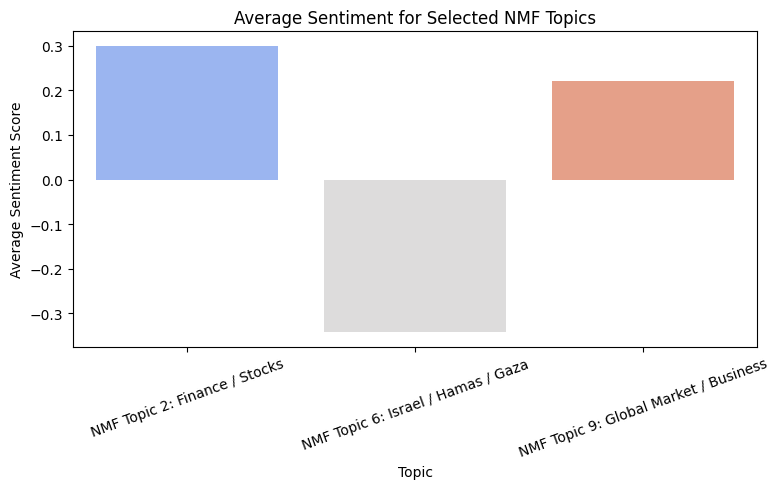

In [31]:
selected_topics_nmf = [1, 5, 8]

for topic_id in selected_topics_nmf:
    topic_df = df[df["nmf_topic"] == topic_id].copy()

    print(f"\nNMF Topic {topic_id + 1}")
    print("Number of articles:", topic_df.shape[0])
    print("Average sentiment score:", topic_df["sentiment_score"].mean())
    print(topic_df["sentiment_label"].value_counts(dropna=False))

# Ensure all selected topics are included, even if no articles
all_topics_df = pd.DataFrame({"nmf_topic": selected_topics_nmf})

topic_summary = (
    df[df["nmf_topic"].isin(selected_topics_nmf)]
    .groupby("nmf_topic")["sentiment_score"]
    .agg(["mean", "count"])
    .reset_index()
)

topic_summary = all_topics_df.merge(topic_summary, on="nmf_topic", how="left").fillna({"mean": 0, "count": 0})

topic_mapping = {
    1: "NMF Topic 2: Finance / Stocks",
    5: "NMF Topic 6: Israel / Hamas / Gaza",
    8: "NMF Topic 9: Global Market / Business"
}

topic_summary["Topic Name"] = topic_summary["nmf_topic"].map(topic_mapping)

plt.figure(figsize=(8, 5))
sns.barplot(data=topic_summary, x="Topic Name", y="mean", palette="coolwarm")
plt.title("Average Sentiment for Selected NMF Topics")
plt.xlabel("Topic")
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
